# **Rock Paper Scissors**

---



### **Overview**


### **Dataset**

In [1]:
!curl -L https://app.roboflow.ai/ds/h6I8GnXgie?key=gKKAX8LVWV | jar -x

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    68  100    68    0     0    237      0 --:--:-- --:--:-- --:--:--   237
100   896  100   896    0     0    634      0  0:00:01  0:00:01 --:--:--  1065
 99  808M   99  803M    0     0  26.7M      0  0:00:30  0:00:29  0:00:01 21.8M
curl: (23) Failure writing output to destination


In [2]:
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.nn.functional as F

import random
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.facecolor'] = '#ffffff'

from PIL import Image
import os

### **Reorganizing the Dataset**
For further convenience, we reogranize the dataset so that the images are put into folders which correspond to their classes.

In [3]:
class RockPaperScissorsDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.transform = transform
        self.images = sorted([file for file in os.listdir(directory) if file.endswith('.jpg')])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = os.path.join(self.directory, self.images[idx])
        image = Image.open(img_name)

        label_file = img_name.replace('.jpg', '.txt')
        label = 3  # Other label
        bbox = [0, 0, 0, 0]  # Default bbox

        if os.path.getsize(label_file) > 0:
            with open(label_file, 'r') as f:
                line = f.readline().strip().split(' ')
                label = int(line[0]) if line[0].isdigit() else 3
                bbox = [float(coord) for coord in line[1:]]

        sample = {
            'image': image if not self.transform else self.transform(image),
            'label': torch.tensor(label, dtype=torch.long),
            'bbox': torch.tensor(bbox, dtype=torch.float)}

        return sample

PyTorch's default collate function, used by the DataLoader, expects each item in a batch to have the same shape. However, in our dataset, different images have a different number of objects, leading to a variable number of labels and bounding boxes for each image.

Also, since there are varying number of bounding boxes, we will pad the bounding boxes to match the sizes.

In [4]:
from torch.utils.data import DataLoader
import torchvision
data_transforms = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

train_dir = '/content/train/'
val_dir = '/content/valid/'
test_dir = '/content/test/'

# Instantiate the datasets
train_dataset = RockPaperScissorsDataset(directory=train_dir, transform=data_transforms)
val_dataset = RockPaperScissorsDataset(directory=val_dir, transform=data_transforms)
test_dataset = RockPaperScissorsDataset(directory=test_dir, transform=data_transforms)

As a test, let's display one instance of the training set along with its label and bounding box

In [5]:
print(len(train_dataset), len(val_dataset), len(test_dataset))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=2, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=2, num_workers=2, pin_memory=True)
print(len(train_loader), len(val_loader), len(test_loader))

14966 588 320
468 294 160


To better use a GPU we will use the helper functions and class used in one of the assignments

In [6]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) or dictionary of tensors to chosen device"""
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    elif isinstance(data, dict):
        return {k: to_device(v, device) if torch.is_tensor(v) else v for k, v in data.items()}
    elif torch.is_tensor(data):
        return data.to(device, non_blocking=True)
    else:
        return data

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

### **Classification**


In [7]:
class ClassificationBase(nn.Module):

    def training_step(self, batch):
        images, labels, bboxes = batch['image'], batch['label'], batch['bbox']
        class_logits, bbox_coords = self(images)
        class_loss = F.cross_entropy(class_logits, labels)
        bbox_loss = F.mse_loss(bbox_coords, bboxes)
        total_loss = class_loss + bbox_loss
        acc = accuracy(class_logits, labels)  # Calculate accuracy
        return total_loss

    def validation_step(self, batch):
        images, labels, bboxes = batch['image'], batch['label'], batch['bbox']
        class_logits, bbox_coords = self(images)
        class_loss = F.cross_entropy(class_logits, labels)
        bbox_loss = F.mse_loss(bbox_coords, bboxes)
        total_loss = class_loss + bbox_loss
        acc = accuracy(class_logits, labels)  # Calculate accuracy
        return {'val_loss': total_loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_acc = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_acc).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']))


def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))


In [8]:
class Classification(ClassificationBase):
    def __init__(self):
        super().__init__()
        self.base_layer = nn.Sequential(
            # input: 3 x 640 x 640
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # output: 32 x 320 x 320

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # output: 64 x 160 x 160

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # output: 128 x 80 x 80

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # output: 256 x 40 x 40

            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # output: 512 x 20 x 20

            nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # output: 1024 x 10 x 10

            nn.Flatten(),
            nn.Linear(1024 * 10 * 10, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU()
        )

        self.classifier = nn.Linear(512, 4)  # Assuming 4 classes
        self.regressor = nn.Linear(512, 4)  # Assuming 4 values for bbox coordinates

    def forward(self, xb):
        features = self.base_layer(xb)
        class_logits = self.classifier(features)
        bbox_coords = self.regressor(features)
        return class_logits, bbox_coords


We will use learning rate scheduler - a technique that changes the learning rate over the course of training according to a predefined strategy. This technique is used to:

> Avoid Overfitting: A high learning rate at the beginning of training helps the model to learn fast, but as training progresses, reducing the learning rate helps the model to converge by making finer updates to the weights.

> Improve Convergence: Sometimes, a model might get stuck in a local minimum with a constant learning rate. Reducing the learning rate can help the model to escape local minima and find a better minimum



In [9]:
def evaluate(model, val_loader):
    model.eval()
    outputs = []
    for batch in val_loader:
        outputs.append(model.validation_step(batch))
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.Adam):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_losses.append(loss.detach())

        scheduler.step()  # Adjust the learning rate

        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)

    return history



In [10]:
model = Classification()
device = get_default_device()
train_loader = DeviceDataLoader(train_loader, device)
val_loader = DeviceDataLoader(val_loader, device)

In [11]:
model.eval()  # Set the model to evaluation mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)  # Move the model to the appropriate device

Classification(
  (base_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(

In [12]:
with torch.no_grad():
    for batch in train_loader:
        images = batch['image'].to(device)

        labels = batch['label'].to(device)
        bboxes = batch['bbox'].to(device)

        print('images.shape:', images.shape)

        # Get predictions from the model
        class_logits, bbox_preds = model(images)
        print('logits.shape:', class_logits.shape)
        print('logits[0]:', class_logits[0])

        print('bbox_preds.shape:', bbox_preds.shape)
        print('bbox_preds[0]:', bbox_preds[0])
        break

images.shape: torch.Size([32, 3, 640, 640])
logits.shape: torch.Size([32, 4])
logits[0]: tensor([-0.0347,  0.0270, -0.0418,  0.0212])
bbox_preds.shape: torch.Size([32, 4])
bbox_preds[0]: tensor([ 0.0334, -0.0109, -0.0200,  0.0180])


Before we begin training, let's initialize the model and see how it performs on the validation set with the initial set of parameters.

In [13]:
model = Classification()
device = get_default_device()
model.to(device)
evaluate(model, val_loader)

{'val_loss': 1.5338335037231445, 'val_acc': 0.42006802558898926}

In [14]:
num_epochs = 5
lr = 0.001

In [52]:
history = fit(num_epochs, lr, model, train_loader, val_loader)

OutOfMemoryError: ignored

In [40]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs')

def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs')

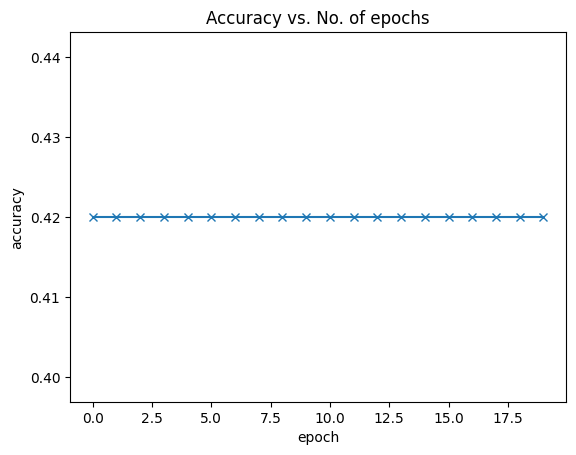

In [41]:
plot_accuracies(history)

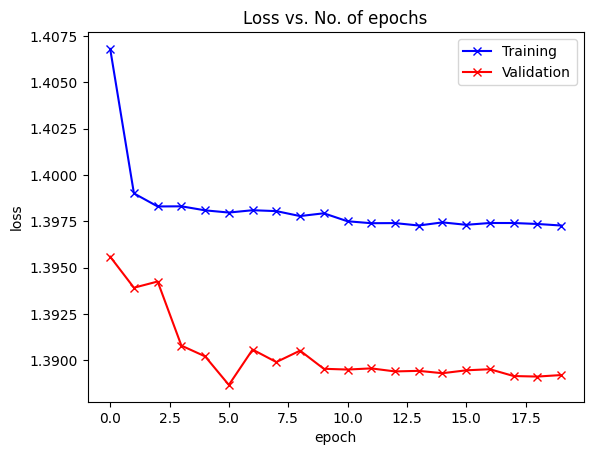

In [42]:
plot_losses(history)

In [ ]:
model_state = model.state_dict()
torch.save(model_state, 'GG.pth')
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p '/content/drive/My Drive/Final Project'
torch.save(model_state, '/content/drive/My Drive/Final Project/GG.pth')


Mounted at /content/drive


In [ ]:
test_loader = DeviceDataLoader(test_loader, device)
result = evaluate(model, test_loader)
result

{'val_loss': 0.38493451476097107, 'val_f1': 0.0}

_______________________________

### **Comparing our model with a pre-trained model**

In [ ]:
import os
import torch
from IPython.display import Image, clear_output
print('PyTorch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))

PyTorch 2.1.0+cu121 _CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=15102MB, multi_processor_count=40)
